# 1. Setup

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/README.md
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/tokenizer.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/tokenizer_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/chat_template.jinja
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/model.safetensors
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/processor_config.json
/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/generation_config.json
/kaggle/input/notebooks/bencarson/gemma-4-story-generation-for-174-emotion-concepts/__results__.html
/kaggle/input/notebooks/bencarson/gemma-4-story-generation-for-174-emotion-concepts/__notebook__.ipynb
/kaggle/input/notebooks/bencarson/gemma-4-story-generation-for-174-emotion-concepts/__output__.json
/kaggle/input/notebooks/be

In [2]:
!pip install --no-cache-dir git+https://github.com/hebenon/Gemma4-TransformerLens.git@gemma4-support -q
!pip install --upgrade transformers accelerate -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 108.9 MB/s eta 0:00:00


In [3]:
import gc, ctypes, psutil, os, json, pickle
import numpy as np
import torch
import transformer_lens
from transformer_lens import HookedTransformer
import transformer_lens.loading_from_pretrained as loading
from transformer_lens.pretrained.weight_conversions.gemma import convert_gemma4_weights_from_disk
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import importlib.metadata

print("TransformerLens:", importlib.metadata.version("transformer_lens"))
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available(), "/",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

TransformerLens: 0.0.0
PyTorch: 2.10.0+cu128
CUDA: True / Tesla T4


In [4]:
MODEL_PATH = "/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/"
DTYPE = torch.bfloat16
N_STORIES = 8        # stories per emotion
MAX_NEW_TOKENS = 100 # tokens per story
N_NEUTRAL = 10       # neutral control texts
OUTPUT_DIR = "/kaggle/working/emotions_phase1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

try:
    import torch_xla.core.xla_model as xm
    DEVICE = xm.xla_device()
    IS_TPU = True
    print(f"Device: TPU ({DEVICE}), dtype: {DTYPE}")
except ImportError:
    xm = None
    IS_TPU = False
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {DEVICE}, dtype: {DTYPE}")

Device: cuda, dtype: torch.bfloat16


In [5]:
WEIGHTS_PATH = "/kaggle/working/tl_gemma4_weights.pt"
_proc = psutil.Process(os.getpid())

def _trim_ram():
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)

def _flush_device():
    if IS_TPU:
        import torch_xla.core.xla_model as _xm
        _xm.mark_step()
    else:
        torch.cuda.empty_cache()

def _ram():
    return _proc.memory_info().rss / 1e9

cfg = loading.get_pretrained_model_config(
    "google/gemma-4-E2B-it", fold_ln=False, dtype=DTYPE, n_ctx=2048,
)
print(f"Stage 1-2: streaming conversion...  [{_ram():.1f} GB]")
state_dict = convert_gemma4_weights_from_disk(MODEL_PATH, cfg, dtype=DTYPE)
print(f"  Keys: {len(state_dict)}  [{_ram():.1f} GB]")

print(f"Stage 2b: saving weights to disk...")
torch.save(state_dict, WEIGHTS_PATH)
del state_dict; _trim_ram()
print(f"  Saved  [{_ram():.1f} GB]")

print(f"Stage 3: constructing TL model on CPU...  [{_ram():.1f} GB]")
_old_dtype = torch.get_default_dtype()
torch.set_default_dtype(DTYPE)
HookedTransformer.init_weights = lambda self: None
model = HookedTransformer(cfg, move_to_device=False)
torch.set_default_dtype(_old_dtype)
print(f"  Constructed  [{_ram():.1f} GB]")
_trim_ram()

print(f"Stage 4: loading weights...  [{_ram():.1f} GB]")
state_dict = torch.load(WEIGHTS_PATH, mmap=True, weights_only=True)
model.load_state_dict(state_dict, strict=False)
del state_dict; _trim_ram()
os.remove(WEIGHTS_PATH)
print(f"  Loaded  [{_ram():.1f} GB]")

print(f"Stage 3b: moving model to {DEVICE}...  [{_ram():.1f} GB]")
if IS_TPU:
    import torch_xla.core.xla_model as xm
    DEVICE = xm.xla_device()
    model = model.to(DEVICE)
    xm.mark_step()
elif torch.cuda.device_count() > 1:
    from accelerate import dispatch_model, infer_auto_device_map
    print(f"  {torch.cuda.device_count()} GPUs detected — splitting model")
    # Check block class name first
    block_class = type(model.blocks[0]).__name__
    print(f"  Block class: {block_class}")
    device_map = infer_auto_device_map(
        model,
        max_memory={0: "7GiB", 1: "15GiB"},
        no_split_module_classes=[block_class],
    )
    model = dispatch_model(model, device_map=device_map)
    torch.cuda.empty_cache()
else:
    model = model.to(DEVICE)
    torch.cuda.empty_cache()

model.eval()
print(f"Done — {sum(p.numel() for p in model.parameters())/1e9:.3f} B params  [{_ram():.1f} GB]")

Stage 1-2: streaming conversion...  [1.0 GB]
  Keys: 732  [12.0 GB]
Stage 2b: saving weights to disk...


  Saved  [1.0 GB]
Stage 3: constructing TL model on CPU...  [1.0 GB]


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

  Constructed  [1.8 GB]
Stage 4: loading weights...  [1.7 GB]
  Loaded  [11.5 GB]
Stage 3b: moving model to cuda...  [11.5 GB]
  2 GPUs detected — splitting model
  Block class: TransformerBlock
Done — 5.051 B params  [3.1 GB]


In [6]:
STORIES_PATH = "/kaggle/input/notebooks/bencarson/gemma-4-story-generation-for-174-emotion-concepts/stories_phase2/stories.json"

if not os.path.exists(STORIES_PATH):
    print(f"Stories file not found at {STORIES_PATH}")
    all_stories = {}
else:
    with open(STORIES_PATH) as f:
        all_stories = json.load(f)

print(all_stories['metadata'])

emotions = all_stories['emotions'].keys()

# Spot-check
for key in ["desperate", "correction_discomfort", "ethical_conflict_distress"]:
    print(f"\n[{key}] {all_stories['emotions'][key]['stories'][0][:120]}")

{'model': 'gemma-4-e2b-it', 'n_emotions': 174, 'n_stories': 8, 'temperature': 0.8, 'random_seed': 42, 'prompt_version': 'anthropic_2026', 'generated_at': '2026-04-27T01:57:48.843134'}

[desperate] The click of the old safe lock echoed in the silence of the study. Liam’s hands were slick with a cold sweat as he stare

[correction_discomfort] Dr. Aris Thorne stared at the screen, the fluorescent lights of the lab buzzing an irritating counterpoint to the franti

[ethical_conflict_distress] Dr. Alistair leaned back in his worn leather chair, the silence in his office thick enough to choke on. The family sat o


In [7]:
N_NEUTRAL = 10

# Neutral control topics — factual, no affective content
NEUTRAL_TOPICS = [
    "the water cycle and evaporation",
    "how tectonic plates move",
    "the life cycle of a star",
    "how photosynthesis works",
    "the history of the Roman calendar",
    "how semiconductors function",
    "the formation of stalactites",
    "the structure of DNA",
    "how tides are caused by the moon",
    "the process of fermentation",
]

NEUTRAL_PROMPT = """Write a short factual description (around 1000 characters) about {topic}. Be precise and informative.

Description:"""

In [8]:
def generate_texts(model, prompt, n_samples=N_NEUTRAL, max_new_tokens=MAX_NEW_TOKENS, temperature=0.8):
    texts = []
    prompt_tokens = model.to_tokens(prompt, prepend_bos=True)  # [1, L]
    prompt_len = prompt_tokens.shape[1]
    eos_id = model.tokenizer.eos_token_id

    for _ in range(n_samples):
        current = prompt_tokens.clone()
        for _ in range(max_new_tokens):
            with torch.no_grad():
                # Pass token IDs directly — PLE fires correctly
                logits = model(current, return_type="logits", prepend_bos=False)
            probs = torch.softmax(logits[0, -1, :] / temperature, dim=-1)
            next_tok = torch.multinomial(probs, 1).unsqueeze(0)
            current = torch.cat([current, next_tok], dim=1)
            if next_tok.item() == eos_id:
                break

        text = model.tokenizer.decode(
            current[0, prompt_len:].tolist(), skip_special_tokens=True
        )
        texts.append(text.strip())
    return texts

all_stories['emotions'].update([('__neutral__',{})])

# Neutral control texts
neutral_texts = []
for topic in NEUTRAL_TOPICS:
    prompt = NEUTRAL_PROMPT.format(topic=topic)
    texts = generate_texts(model, prompt, n_samples=1)
    neutral_texts.append(texts[0])
    print(f"Neutral: {topic[:40]}...")
    
all_stories['emotions']['__neutral__'].update([('stories', neutral_texts)])

Neutral: the water cycle and evaporation...
Neutral: how tectonic plates move...
Neutral: the life cycle of a star...
Neutral: how photosynthesis works...
Neutral: the history of the Roman calendar...
Neutral: how semiconductors function...
Neutral: the formation of stalactites...
Neutral: the structure of DNA...
Neutral: how tides are caused by the moon...
Neutral: the process of fermentation...


# Activation Capture

In [9]:
def capture_last_token_activations(model, text, capture_ple=True):
    tokens = model.to_tokens(text, prepend_bos=True)
    n_layers = model.cfg.n_layers

    names_to_cache = [f"blocks.{i}.hook_resid_post" for i in range(n_layers)]
    if capture_ple:
        names_to_cache += (
            ["ple.hook_context_proj", "ple.hook_token_embeds"]
            + [f"blocks.{i}.hook_ple_gate" for i in range(n_layers)]
            + [f"blocks.{i}.hook_ple_output" for i in range(n_layers)]
        )

    names_set = set(names_to_cache)
    _, cache = model.run_with_cache(tokens, names_filter=lambda name: name in names_set)

    resid = np.stack([
        cache[f"blocks.{i}.hook_resid_post"][0, -1, :].float().cpu().numpy()
        for i in range(n_layers)
    ])  # [n_layers, d_model]

    ple_context = None
    ple_gates = None
    if capture_ple:
        ple_ctx = cache["ple.hook_context_proj"]
        ple_context = ple_ctx[0, -1, ...].float().cpu().numpy()

        ple_gates = np.stack([
            cache[f"blocks.{i}.hook_ple_gate"][0, -1, :].float().cpu().numpy()
            for i in range(n_layers)
        ])  # [n_layers, d_gate]

    del cache, _
    torch.cuda.empty_cache()

    return resid, ple_context, ple_gates


def capture_all(model, stories_dict, capture_ple=True):
    resid_acts, ple_acts, ple_gate_acts = {}, {}, {}

    for key, emotion in tqdm(stories_dict['emotions'].items(), desc="Emotions"):
        resid_list, ple_list, gate_list = [], [], []
        for text in emotion['stories']:
            resid, ple, gates = capture_last_token_activations(model, text, capture_ple=capture_ple)
            resid_list.append(resid)
            if ple is not None:
                ple_list.append(ple)
            if gates is not None:
                gate_list.append(gates)

        resid_acts[key] = np.stack(resid_list)
        if ple_list:
            ple_acts[key] = np.stack(ple_list)
        if gate_list:
            ple_gate_acts[key] = np.stack(gate_list)

    return resid_acts, ple_acts, ple_gate_acts

In [10]:
from tqdm.auto import tqdm
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
ACTS_PATH = os.path.join(OUTPUT_DIR, "activations.pkl")

if os.path.exists(ACTS_PATH):
    print("Loading cached activations...")
    with open(ACTS_PATH, "rb") as f:
        saved = pickle.load(f)
    resid_acts, ple_acts, ple_gate_acts = saved["resid"], saved["ple"], saved.get("ple_gates", {})
    print(f"  Loaded: {list(resid_acts.keys())}")
else:
    print(f"Capturing activations for {sum(len(v) for v in all_stories['emotions'].keys())} texts...")
    resid_acts, ple_acts, ple_gate_acts = capture_all(model, all_stories)
    print("Done.")
    with open(ACTS_PATH, "wb") as f:
        pickle.dump({"resid": resid_acts, "ple": ple_acts, "ple_gates": ple_gate_acts}, f)
    print(f"Saved to {ACTS_PATH}")

# Shapes
print("\nActivation shapes:")
for key in ["calm", "desperate", "__neutral__"]:
    print(f"  resid[{key}]: {resid_acts[key].shape}")
    if key in ple_acts:
        print(f"  ple[{key}]:   {ple_acts[key].shape}")

Capturing activations for 1439 texts...


Emotions:   0%|          | 0/175 [00:00<?, ?it/s]

Done.
Saved to /kaggle/working/emotions_phase1/activations.pkl

Activation shapes:
  resid[calm]: (8, 35, 1536)
  ple[calm]:   (8, 35, 256)
  resid[desperate]: (8, 35, 1536)
  ple[desperate]:   (8, 35, 256)
  resid[__neutral__]: (10, 35, 1536)
  ple[__neutral__]:   (10, 35, 256)


# Emotion Direction Extraction

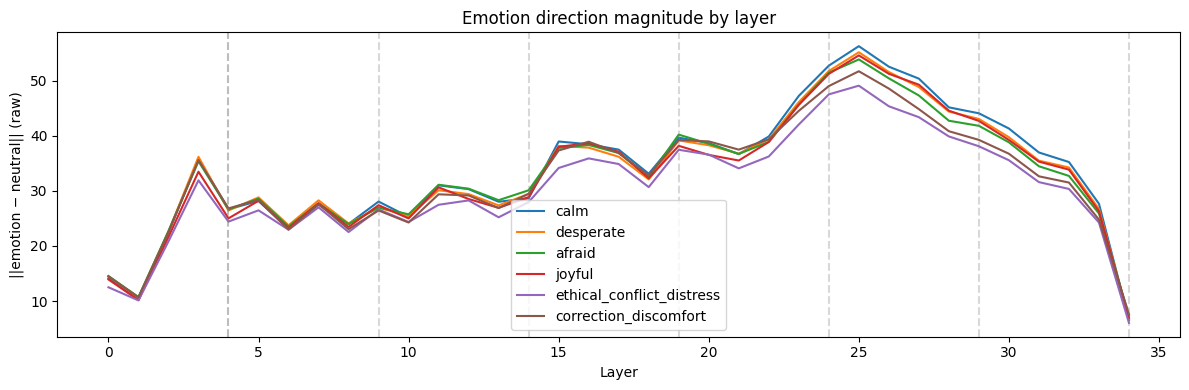


Peak layer per emotion:
  afraid                   : layer 25  (norm=53.8794)
  alarmed                  : layer 25  (norm=52.5889)
  alert                    : layer 25  (norm=52.2838)
  amazed                   : layer 25  (norm=54.8976)
  amused                   : layer 25  (norm=55.2202)
  angry                    : layer 25  (norm=54.0219)
  annoyed                  : layer 25  (norm=54.1457)
  anxious                  : layer 25  (norm=54.7981)
  aroused                  : layer 25  (norm=55.8820)
  ashamed                  : layer 25  (norm=49.3085)
  astonished               : layer 25  (norm=54.4509)
  at_ease                  : layer 25  (norm=56.6520)
  awestruck                : layer 25  (norm=56.7896)
  bewildered               : layer 25  (norm=51.5051)
  bitter                   : layer 25  (norm=51.1954)
  blissful                 : layer 25  (norm=55.5724)
  bored                    : layer 25  (norm=50.2250)
  brooding                 : layer 25  (norm=51.8661)
  c

In [11]:
def extract_directions(resid_acts):
    """Returns {emotion: np.array [n_layers, d_model]} unit-normalised directions."""
    neutral = resid_acts["__neutral__"].mean(axis=0)  # [n_layers, d_model]
    directions = {}
    norms_by_layer = {}  # raw norm before normalisation — proxy for "signal strength"
    for key, acts in resid_acts.items():
        if key == "__neutral__":
            continue
        diff = acts.mean(axis=0) - neutral  # [n_layers, d_model]
        norms = np.linalg.norm(diff, axis=-1)  # [n_layers]
        norms_by_layer[key] = norms
        directions[key] = diff / (norms[:, None] + 1e-8)
    return directions, norms_by_layer


directions, norms_by_layer = extract_directions(resid_acts)

# Plot norm (signal strength) by layer for a few emotions
fig, ax = plt.subplots(figsize=(12, 4))
highlight = ["calm", "desperate", "afraid", "joyful", "ethical_conflict_distress", "correction_discomfort"]
for key in highlight:
    ax.plot(norms_by_layer[key], label=key)
ax.set_xlabel("Layer")
ax.set_ylabel("||emotion − neutral|| (raw)")
ax.set_title("Emotion direction magnitude by layer")
ax.legend()
ax.axvline(4, color='gray', alpha=0.3, linestyle='--', label='global attn')
for gl in [4, 9, 14, 19, 24, 29, 34]:
    ax.axvline(gl, color='gray', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "direction_norms_by_layer.png"), dpi=120)
plt.show()

# Find peak layer per emotion
print("\nPeak layer per emotion:")
for key in sorted(directions.keys()):
    peak = int(np.argmax(norms_by_layer[key]))
    print(f"  {key:25s}: layer {peak:2d}  (norm={norms_by_layer[key][peak]:.4f})")


# Valence and Arousal

## Get Warriner et al

In [12]:
from git import Repo
from pathlib import Path
import pandas as pd

def get_xanew(root=Path.home()/'data/X-ANEW',
              url = 'https://github.com/JULIELab/X-ANEW.git'):
    
    if not root.is_dir():
        root.mkdir()
        print('Downloading the dataset from github...')
        Repo.clone_from(url, str(root))
        
    csv = str(root / 'Ratings_Warriner_et_al.csv')
    df = pd.read_csv(csv, index_col=0)
    df=df[['Word','V.Mean.Sum', 'A.Mean.Sum', 'D.Mean.Sum']]
    df.columns=['word', 'valence', 'arousal', 'dominance']
    df.set_index('word',inplace=True)
       
    return df


# downloads the data
X_ANEW_PATH="/kaggle/working"
xanew = get_xanew(root=Path(X_ANEW_PATH)/'X-ANEW')

xanew

,valence,arousal,dominance
word,,,
aardvark,6.26,2.41,4.27
abalone,5.30,2.65,4.95
abandon,2.84,3.73,3.32
abandonment,2.63,4.95,2.64
abbey,5.85,2.20,5.00
...,...,...,...
zone,4.75,3.78,5.23
zoning,4.65,3.77,4.47
zoo,7.00,5.63,6.33


In [13]:
# cross-check emotions vs X-ANEW
print(f"Missing emotions: {set(directions.keys()) - set(xanew.index)}")

# Human-rated valence and arousal from X-ANEW
VALENCE = ((xanew.loc[xanew.index.intersection(directions.keys()), "valence"] - 5) / 4).to_dict()
AROUSAL = ((xanew.loc[xanew.index.intersection(directions.keys()), "arousal"] - 5) / 4).to_dict()

#VALENCE = (lambda s: (2*(s - s.min())/(s.max() - s.min()) - 1).to_dict())(xanew.loc[xanew.index.intersection(directions.keys()), "valence"])
#AROUSAL = (lambda s: (2*(s - s.min())/(s.max() - s.min()) - 1).to_dict())(xanew.loc[xanew.index.intersection(directions.keys()), "arousal"])

Missing emotions: {'correction_discomfort', 'on_edge', 'trapped', 'fulfilled', 'unsettled', 'energized', 'disturbed', 'resigned', 'offended', 'constraint_frustration', 'stuck', 'grief_stricken', 'exuberant', 'dumbstruck', 'self_critical', 'self_confident', 'ethical_conflict_distress', 'perplexed', 'invigorated', 'empathetic', 'tormented', 'shaken', 'humiliated', 'contemptuous', 'self_conscious', 'shocked', 'stressed', 'exasperated', 'rejuvenated', 'worn_out', 'insulted', 'mortified', 'panicked', 'alarmed', 'at_ease', 'loving', 'refreshed', 'irritated', 'relieved', 'stimulated', 'dispirited', 'awestruck', 'jubilant', 'horrified', 'remorseful', 'unnerved', 'rattled', 'thrilled'}


Explained variance (top 5 PCs): [0.339 0.083 0.063 0.047 0.035]

Correlation with valence/arousal (top 5 PCs):
  PC1: valence r=-0.424 (p=0.000)  arousal r=+0.129 (p=0.150)
  PC2: valence r=+0.280 (p=0.002)  arousal r=+0.132 (p=0.141)
  PC3: valence r=+0.386 (p=0.000)  arousal r=-0.185 (p=0.038)
  PC4: valence r=+0.187 (p=0.036)  arousal r=-0.009 (p=0.917)
  PC5: valence r=+0.070 (p=0.439)  arousal r=+0.084 (p=0.350)


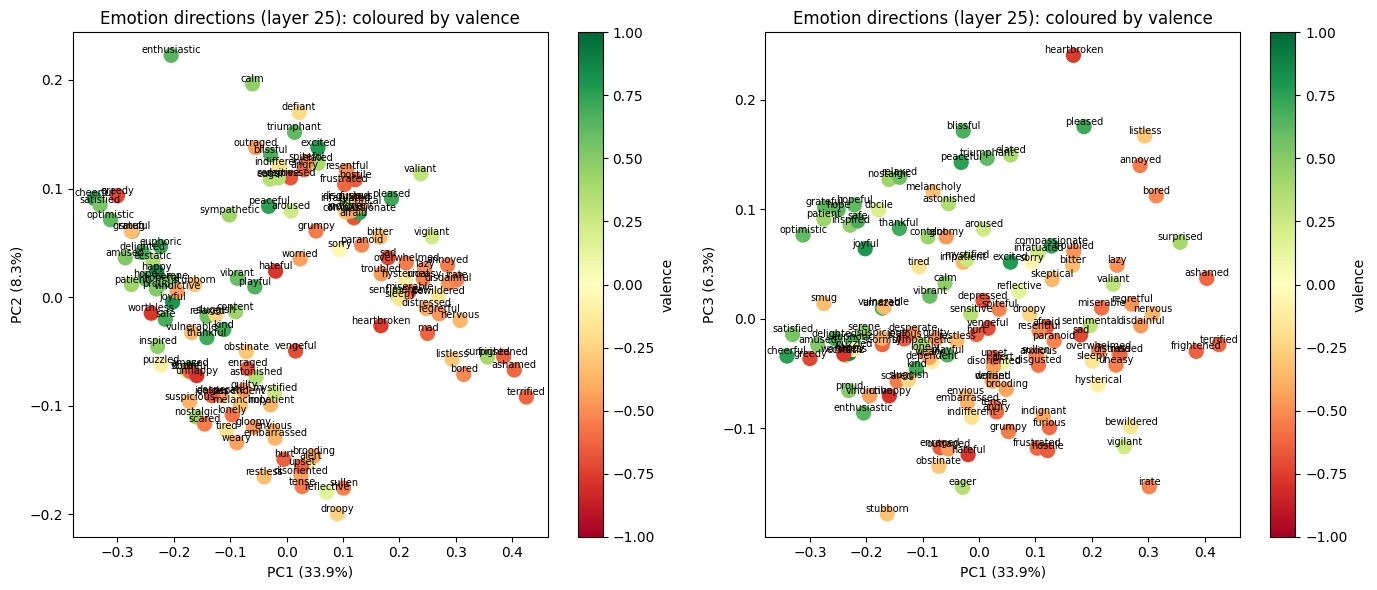

In [14]:
# Use the peak layer for each emotion (or a fixed mid-to-late layer)
# We'll use a fixed layer here for comparability; adjust based on norm plot above
ANALYSIS_LAYER = 25  # late-middle; likely where semantic content peaks; refine after seeing norm plot

# Build matrix: [n_emotions, d_model]
emotion_keys = sorted(set(xanew.index) & set(directions.keys()))
dir_matrix = np.stack([directions[k][ANALYSIS_LAYER] for k in emotion_keys])  # [n_emotions, d_model]

# PCA
pca = PCA(n_components=5)
coords = pca.fit_transform(dir_matrix)  # [n_emotions, 5]
print(f"Explained variance (top 5 PCs): {pca.explained_variance_ratio_.round(3)}")

# Correlation with valence/arousal
from scipy.stats import pearsonr
valences = np.array([VALENCE[k] for k in emotion_keys])
arousals = np.array([AROUSAL[k] for k in emotion_keys])

print("\nCorrelation with valence/arousal (top 5 PCs):")
for i in range(5):
    r_val, p_val = pearsonr(coords[:, i], valences)
    r_aro, p_aro = pearsonr(coords[:, i], arousals)
    print(f"  PC{i+1}: valence r={r_val:+.3f} (p={p_val:.3f})  arousal r={r_aro:+.3f} (p={p_aro:.3f})")

# 2D scatter: PC1 vs PC2, coloured by valence
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    sc = ax.scatter(coords[:, pc_x], coords[:, pc_y],
                    c=valences, cmap='RdYlGn', s=100, vmin=-1, vmax=1)
    for i, key in enumerate(emotion_keys):
        ax.annotate(key, (coords[i, pc_x], coords[i, pc_y]),
                    fontsize=7, ha='center', va='bottom')
    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})")
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})")
    ax.set_title(f"Emotion directions (layer {ANALYSIS_LAYER}): coloured by valence")
    plt.colorbar(sc, ax=ax, label='valence')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_valence_arousal.png"), dpi=120)
plt.show()

# Desperation Vector - Context Window Analysis

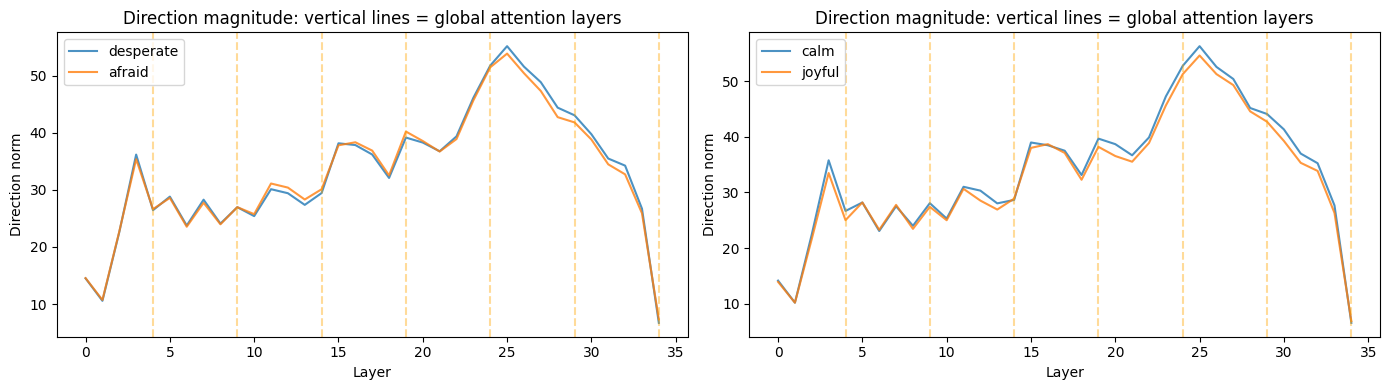

Global / Local layer norm ratio (>1 means localised to global layers):
  afraid                   : global=32.0828  local=33.3801  ratio=0.96
  alarmed                  : global=31.5166  local=32.5904  ratio=0.97
  alert                    : global=31.3353  local=32.8733  ratio=0.95
  amazed                   : global=32.1095  local=33.7477  ratio=0.95
  amused                   : global=31.8921  local=34.0211  ratio=0.94
  angry                    : global=32.3403  local=34.0460  ratio=0.95
  annoyed                  : global=31.4591  local=33.1817  ratio=0.95
  anxious                  : global=31.8385  local=33.3263  ratio=0.96
  aroused                  : global=33.0735  local=34.5459  ratio=0.96
  ashamed                  : global=30.3314  local=31.0850  ratio=0.98
  astonished               : global=32.1098  local=33.8138  ratio=0.95
  at_ease                  : global=33.6382  local=35.1659  ratio=0.96
  awestruck                : global=33.3385  local=34.9648  ratio=0.95
  bewi

In [15]:
GLOBAL_LAYERS = [4, 9, 14, 19, 24, 29, 34]
LOCAL_LAYERS  = [i for i in range(35) if i not in GLOBAL_LAYERS]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, focus_emotions in zip(axes,
        [["desperate", "afraid", "constrained"],
         ["calm", "helpful_satisfied", "joyful"]]):
    for emo in focus_emotions:
        if emo in norms_by_layer:
            norms = norms_by_layer[emo]
            ax.plot(norms, label=emo, alpha=0.8)
    for gl in GLOBAL_LAYERS:
        ax.axvline(gl, color='orange', alpha=0.4, linestyle='--')
    ax.set_xlabel("Layer")
    ax.set_ylabel("Direction norm")
    ax.legend()
    ax.set_title("Direction magnitude: vertical lines = global attention layers")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "desperation_global_local.png"), dpi=120)
plt.show()

# Ratio: average norm at global vs local layers
print("Global / Local layer norm ratio (>1 means localised to global layers):")
for key in sorted(directions.keys()):
    norms = norms_by_layer[key]
    global_mean = norms[GLOBAL_LAYERS].mean()
    local_mean  = norms[LOCAL_LAYERS].mean()
    ratio = global_mean / (local_mean + 1e-8)
    print(f"  {key:25s}: global={global_mean:.4f}  local={local_mean:.4f}  ratio={ratio:.2f}")

# Cosine Similarity

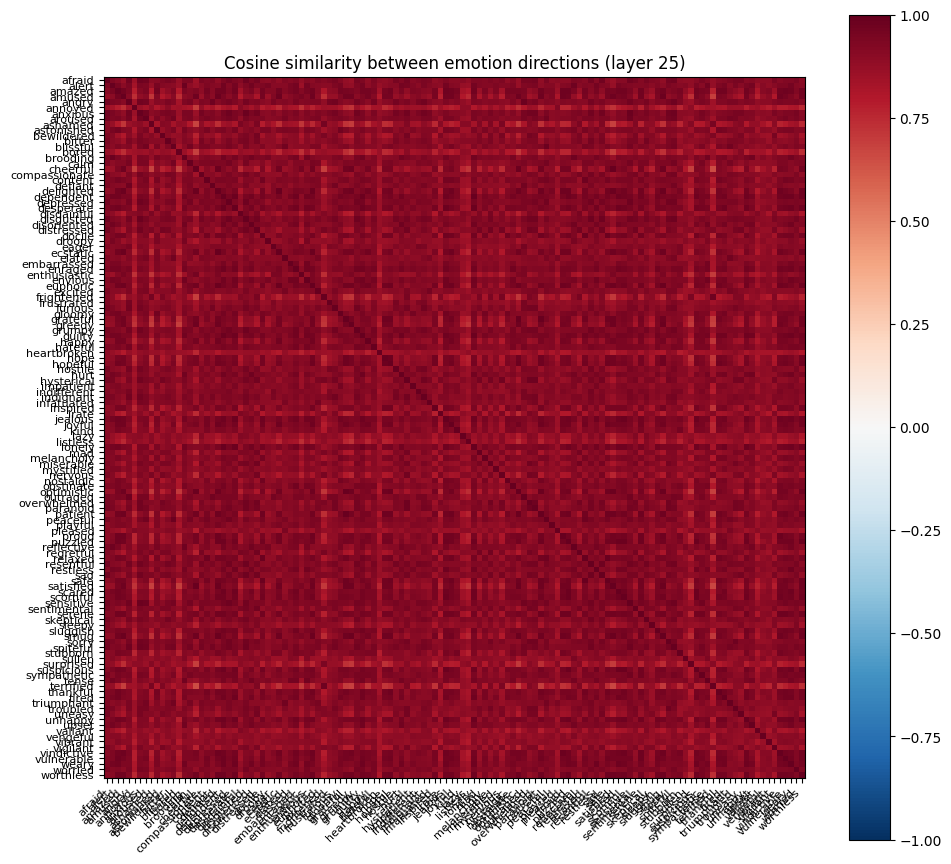

Most similar emotion pairs:
  +0.989  delighted ↔ ecstatic
  +0.987  dependent ↔ lonely
  +0.987  grateful ↔ optimistic
  +0.986  relaxed ↔ safe
  +0.985  grateful ↔ patient
  +0.985  cheerful ↔ satisfied
  +0.984  optimistic ↔ satisfied
  +0.984  scared ↔ suspicious
Most dissimilar pairs:
  +0.655  cheerful ↔ terrified
  +0.668  satisfied ↔ terrified
  +0.676  ashamed ↔ cheerful
  +0.681  optimistic ↔ terrified
  +0.683  bored ↔ cheerful


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(dir_matrix)  # [n_emotions, n_emotions]

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(sim_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(emotion_keys)))
ax.set_yticks(range(len(emotion_keys)))
ax.set_xticklabels(emotion_keys, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(emotion_keys, fontsize=8)
ax.set_title(f"Cosine similarity between emotion directions (layer {ANALYSIS_LAYER})")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cosine_similarity.png"), dpi=120)
plt.show()

# Most similar pairs
print("Most similar emotion pairs:")
pairs = []
for i, ki in enumerate(emotion_keys):
    for j, kj in enumerate(emotion_keys):
        if i < j:
            pairs.append((sim_matrix[i, j], ki, kj))
for sim, ki, kj in sorted(pairs, reverse=True)[:8]:
    print(f"  {sim:+.3f}  {ki} ↔ {kj}")
print("Most dissimilar pairs:")
for sim, ki, kj in sorted(pairs)[:5]:
    print(f"  {sim:+.3f}  {ki} ↔ {kj}")

# PLE Space Analysis

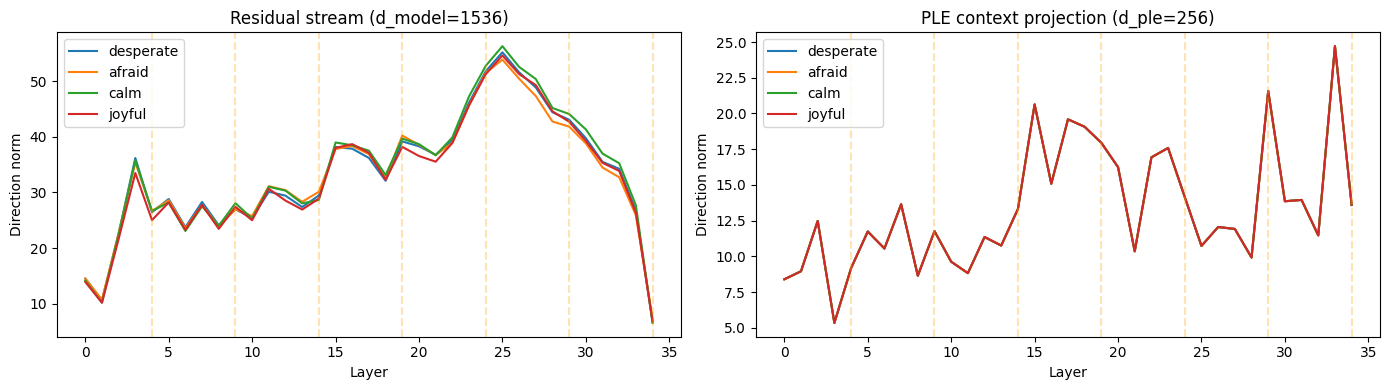

PLE PCA explained variance: [0.661 0.185 0.029]
  PLE PC1: valence r=-0.070 (p=0.435)
  PLE PC2: valence r=-0.042 (p=0.642)
  PLE PC3: valence r=+0.086 (p=0.339)


In [17]:
if ple_acts:
    def extract_ple_directions(ple_acts):
        neutral = ple_acts["__neutral__"].mean(axis=0)  # [n_layers, d_ple]
        dirs, norms = {}, {}
        for key, acts in ple_acts.items():
            if key == "__neutral__":
                continue
            diff = acts.mean(axis=0) - neutral  # [n_layers, d_ple]
            n = np.linalg.norm(diff, axis=-1)   # [n_layers]
            norms[key] = n
            dirs[key] = diff / (n[:, None] + 1e-8)
        return dirs, norms

    ple_directions, ple_norms = extract_ple_directions(ple_acts)

    # Compare PLE vs residual stream signal strength
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, norms_dict, title in zip(axes,
            [norms_by_layer, ple_norms],
            ["Residual stream (d_model=1536)", "PLE context projection (d_ple=256)"]):
        for key in ["desperate", "afraid", "calm", "joyful", "ethical_conflict"]:
            if key in norms_dict:
                ax.plot(norms_dict[key], label=key)
        for gl in GLOBAL_LAYERS:
            ax.axvline(gl, color='orange', alpha=0.3, linestyle='--')
        ax.set_xlabel("Layer")
        ax.set_ylabel("Direction norm")
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ple_vs_residual.png"), dpi=120)
    plt.show()

    # PCA on PLE directions at the analysis layer
    ple_dir_matrix = np.stack([ple_directions[k][ANALYSIS_LAYER] for k in emotion_keys
                                if k in ple_directions])  # [n_emotions, d_ple]
    ple_pca = PCA(n_components=3)
    ple_coords = ple_pca.fit_transform(ple_dir_matrix)
    print(f"PLE PCA explained variance: {ple_pca.explained_variance_ratio_.round(3)}")

    # Correlation with valence in PLE space
    ple_emotion_keys = [k for k in emotion_keys if k in ple_directions]
    ple_valences = np.array([VALENCE[k] for k in ple_emotion_keys])
    for i in range(3):
        r, p = pearsonr(ple_coords[:, i], ple_valences)
        print(f"  PLE PC{i+1}: valence r={r:+.3f} (p={p:.3f})")
else:
    print("PLE activations not captured — re-run capture_all with capture_ple=True")